# 13장 - 멀티에이전트 RAG

원본 파일: `chap13/multi_agent_rag.py`

In [16]:
from typing import List, Literal
from typing_extensions import TypedDict
from langgraph.graph import START, StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import os

import build_vectorstore

load_dotenv()

model = ChatOpenAI(
    model="openai/gpt-4o-mini",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv('OPENAI_API_KEY'),
)

vectorstore = build_vectorstore.build()
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

Loading existing Chroma store


In [17]:
class RouteQuery(BaseModel):
    """사용자 쿼리를 가장 관련성이 높은 데이터 소스로 라우팅합니다."""

    datasource: Literal["vectorstore", "casual_talk"] = Field(
        ...,
        description="""
        사용자 질문에 따라 casual_talk 또는 vectorstore로 라우팅합니다.
        - casual_talk: 일상 대화를 위한 데이터 소스. 사용자가 일상적인 질문을 할 때 사용합니다.
        - vectorstore: 사용자 질문에 답하기 위해 RAG로 vectorstore 검색이 필요한 경우 사용합니다.
        """,
    )

In [18]:
structured_llm_router = model.with_structured_output(RouteQuery)

router_system = """
당신은 사용자의 질문을 vectorstore 또는 casual_talk으로 라우팅하는 전문가입니다.
- vectorstore에는 서울, 뉴욕의 발전계획과 관련된 문서가 포함되어 있습니다. 이 주제에 대한 질문에는 vectorstore를 사용하십시오.
- 사용자의 질문이 일상 대화에 관련된 경우 casual_talk을 사용하십시오.
"""
route_prompt = ChatPromptTemplate.from_messages([
    ("system", router_system),
    ("human", "{question}"),
])
question_router = route_prompt | structured_llm_router

In [19]:
class GradeDocuments(BaseModel):
    """검색된 문서가 질문과 관련성 있는지 yes 또는 no로 평가합니다."""

    binary_score: Literal["yes", "no"] = Field(
        description="문서가 질문과 관련이 있는지 여부를 'yes' 또는 'no'로 평가합니다."
    )

In [20]:
structured_llm_grader = model.with_structured_output(GradeDocuments)

grader_prompt = PromptTemplate.from_template("""
당신은 검색된 문서가 사용자 질문과 관련이 있는지 평가하는 평가자입니다.
문서에 사용자 질문과 관련된 키워드 또는 의미가 포함되어 있으면, 해당 문서를 관련성이 있다고 평가하십시오.
엄격한 테스트가 필요하지 않습니다. 목표는 잘못된 검색 결과를 걸러내는 것입니다.
문서가 질문과 관련이 있는지 여부를 나타내기 위해 'yes' 또는 'no'로 이진 점수를 부여하십시오.

Retrieved document: \n {document} \n\n
User question: {question}
""")
retrieval_grader = grader_prompt | structured_llm_grader


# ---------- 3) 검색된 문서를 바탕으로 답변 생성 ----------
rag_generate_system = """
너는 사용자의 질문에 대해 주어진 context에 기반하여 답변하는 도시 계획 전문가이다.
주어진 context는 vectorstore에서 검색된 결과이다.
주어진 context를 기반으로 사용자의 question에 대해 답변하라.

====================================
question: {question}
context: {context}
"""
rag_prompt = PromptTemplate(
    input_variables=["question", "context"],
    template=rag_generate_system,
)
rag_chain = rag_prompt | model

In [21]:
class GraphState(TypedDict):
    question: str  # 사용자 질문
    generation: str  # LLM 생성 결과
    documents: List[str]  # 검색된 문서

In [22]:
def route_question(state):
    """사용자 질문을 vectorstore 또는 casual_talk로 라우팅합니다."""
    print('------ROUTE------')
    question = state['question']
    route = question_router.invoke({"question": question})
    print(f"---Routing to {route.datasource}---")
    return route.datasource

In [23]:
def retrieve(state):
    """vectorstore에서 질문에 대한 문서를 검색합니다."""
    print('------RETRIEVE------')
    question = state['question']
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

In [24]:
def grade_documents(state):
    """검색된 문서를 평가하여 질문과 관련성이 있는지 확인합니다."""
    print('------GRADE------')
    question = state['question']
    documents = state['documents']
    filtered_docs = []
    for i, doc in enumerate(documents):
        is_relevant = retrieval_grader.invoke({"question": question, "document": doc.page_content})
        if is_relevant.binary_score == "yes":
            filtered_docs.append(doc)
    return {"documents": filtered_docs, "question": question}

In [25]:
def generate(state):
    """LLM을 사용하여 문서와 사용자 질문에 대한 답변을 생성합니다."""
    print('------GENERATE------')
    question = state['question']
    documents = state['documents']
    generation = rag_chain.invoke({"question": question, "context": documents})
    return {
        "documents": documents,
        "question": question,
        "generation": generation,
    }

In [26]:
def casual_talk(state):
    """일상 대화를 위한 답변을 생성합니다."""
    print('------CASUAL TALK------')
    question = state['question']
    generation = model.invoke(question)
    return {
        "question": question,
        "generation": generation,
    }

In [27]:
workflow = StateGraph(GraphState)

workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("casual_talk", casual_talk)

workflow.add_conditional_edges(
    START,
    route_question,
    {
        "vectorstore": "retrieve",
        "casual_talk": "casual_talk",
    },
)
workflow.add_edge("casual_talk", END)
workflow.add_edge("retrieve", "grade_documents")
workflow.add_edge("grade_documents", "generate")
workflow.add_edge("generate", END)

app = workflow.compile()

## 그래프 구조 시각화

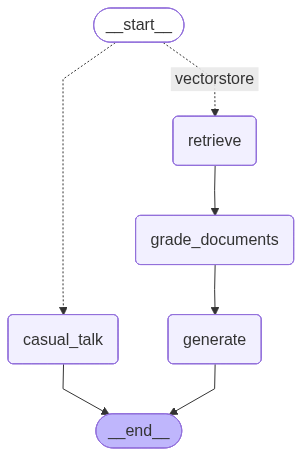

In [28]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # 실패 시 통과 (mermaid 렌더링 서버 접속 불가 등)
    pass

## 실행 / 테스트

In [29]:
print("===== 1. RAG로 라우팅되는 질문 =====")
result = app.invoke({"question": "서울시 자율주행 관련 계획"})
print(result["generation"].content)

===== 1. RAG로 라우팅되는 질문 =====
------ROUTE------


/Users/seminy/Desktop/Main/Git/AI_Bootcamp/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteQuery(datasource='vectorstore'), input_type=RouteQuery])
  return self.__pydantic_serializer__.to_python(


---Routing to vectorstore---
------RETRIEVE------
------GRADE------


/Users/seminy/Desktop/Main/Git/AI_Bootcamp/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeDocuments(binary_score='yes'), input_type=GradeDocuments])
  return self.__pydantic_serializer__.to_python(
/Users/seminy/Desktop/Main/Git/AI_Bootcamp/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeDocuments(binary_score='yes'), input_type=GradeDocuments])
  return self.__pydantic_serializer__.to_python(
/Users/seminy/Desktop/Main/Git/AI_Bootcamp/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be a

------GENERATE------
서울시는 자율주행 기술과 관련하여 여러 가지 계획을 세우고 있습니다. 미래교통 인프라의 구축을 목표로 하여, 자율주행 자동차의 본격 운영 체계 구축을 추진하고 있으며, 이를 통해 2030년까지 간선도로급 이상 도로에서 자율주행 차량이 운영될 수 있는 환경을 조성할 계획입니다. 또한, 2040년까지 서울 전역에서 자율주행 차량의 운행 환경을 구축하고, 수송 분담률을 10% 달성하는 것을 목표로 하고 있습니다.

이와 함께 서울은 도심 항공교통(UAM)의 기반을 마련하고, 주요 수변 공간을 중심으로 상용화 노선을 확보할 계획입니다. 서울 전역에 모빌리티 허브를 구축하여, 다양한 교통 수단과 기존 교통을 연결하는 통합 교통 체계를 만들어갈 예정입니다.

이러한 계획은 기술 발전에 선제적으로 대응하고, 안전하고 효율적인 교통 환경을 조성하기 위한 노력이 일환으로, 새로운 교통수단의 도입과 관련하여 통합적인 가이드라인과 인프라 확충이 필요하다는 점도 강조되고 있습니다.


In [30]:
print("\n===== 2. 일상 대화로 라우팅되는 질문 =====")
result = app.invoke({"question": "잘 지내고 있어?"})
print(result["generation"].content)


===== 2. 일상 대화로 라우팅되는 질문 =====
------ROUTE------


/Users/seminy/Desktop/Main/Git/AI_Bootcamp/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteQuery(datasource='casual_talk'), input_type=RouteQuery])
  return self.__pydantic_serializer__.to_python(


---Routing to casual_talk---
------CASUAL TALK------
네, 잘 지내고 있어요! 당신은 어떻게 지내고 있나요?
